Dataset size: 1008
                                                 url  source  \
0  https://dev.to/dannwaneri/were-creating-a-know...  dev.to   
1  https://dev.to/rachynska/if-its-not-accessible...  dev.to   

                                               title   author  \
0  We're Creating a Knowledge Collapse and No One...  Unknown   
1            If It's Not Accessible, It's Not Design  Unknown   

           published_at                                            content  \
0  2026-01-27T01:59:58Z  "Hostile experts created the dataset for patie...   
1  2026-01-26T22:32:03Z  When I first started my career in UX/UI design...   

                           tags  error  \
0  #ai,#webdev,#career,#discuss    NaN   
1     #ux,#design,#a11y,#webdev    NaN   

                                           full_text  text_length  
0  We're Creating a Knowledge Collapse and No One...        18213  
1  If It's Not Accessible, It's Not Design. When ...         7431  


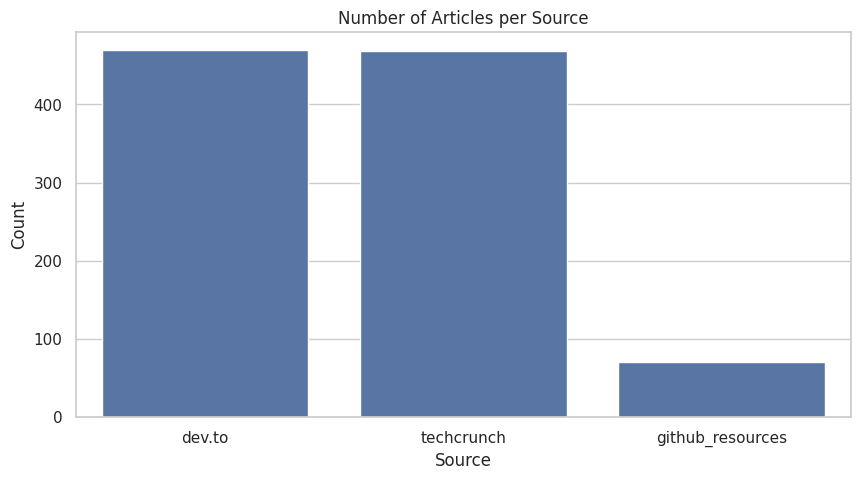

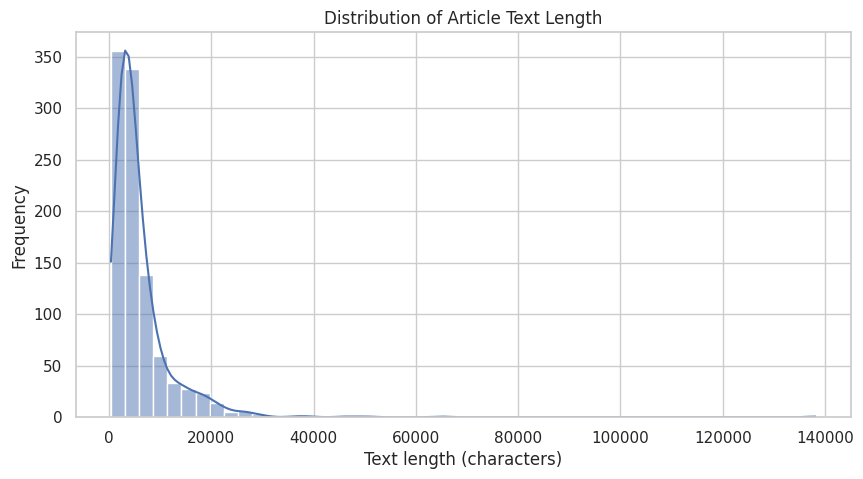

/tmp/ipykernel_21256/3679414082.py:44: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")


AttributeError: Can only use .dt accessor with datetimelike values

In [1]:
# ===============================
# EXPLORATORY DATA ANALYSIS (EDA)
# Matplotlib + Seaborn
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load cleaned data
df = pd.read_csv("../data/processed/articles_cleaned.csv")

print("Dataset size:", len(df))
print(df.head(2))

# --------------------------------
# 1) Articles per source
# --------------------------------
plt.figure()
sns.countplot(data=df, x="source", order=df["source"].value_counts().index)
plt.title("Number of Articles per Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.show()

# --------------------------------
# 2) Text length distribution
# --------------------------------
plt.figure()
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("Distribution of Article Text Length")
plt.xlabel("Text length (characters)")
plt.ylabel("Frequency")
plt.show()

# --------------------------------
# 3) Publication timeline
# --------------------------------
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")
df_time = df.dropna(subset=["published_at"])

df_time["month"] = df_time["published_at"].dt.to_period("M").astype(str)

plt.figure(figsize=(12, 5))
df_time["month"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Articles Published Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

# --------------------------------
# 4) Top tags (blogs metadata)
# --------------------------------
tags_series = (
    df["tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_tags = tags_series.value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tags.values, y=top_tags.index)
plt.title("Top 15 Most Frequent Tags")
plt.xlabel("Frequency")
plt.ylabel("Tag")
plt.show()

# --------------------------------
# 5) Articles per author (Top 10)
# --------------------------------
top_authors = df["author"].value_counts().head(10)

plt.figure()
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top 10 Authors")
plt.xlabel("Number of Articles")
plt.ylabel("Author")
plt.show()

# --------------------------------
# 6) Source vs text length
# --------------------------------
plt.figure()
sns.boxplot(data=df, x="source", y="text_length")
plt.title("Article Length by Source")
plt.xlabel("Source")
plt.ylabel("Text Length (chars)")
plt.show()
